This notebook shows the sampling of Emerald+ summoners across 3 regions (Europe West, Korea, North America). First get_summoner_list.py was run to acquire the list of all summoners in the 3 regions that are ranked Emerald and above. The amount and distribution are shown in the first graph. Match histories were then queried from a simple random sampling of the list of summoners. Because League of Legends is a 5v5 player game with skill-based matchmaking, for each game associated with an Emerald+ player, there are 9 other players in that game who are also likely Emerald+. Thus, there is significantly diminishing returns in the amount of unique games gained by querying more and more players. However, to be sure that we have a good coverage in the games queried, we need to check if our random sampling was appropriately done.

Note: Although I refer to the process of querying summoners as a "sampling", my intention was to collect a vast majority of matches played across the time period of a game patch. I wanted as much data as possible to have as many observations of champion matchups as possible, especially given the large roster of champions in LoL and the combinatorics nature of the problem. So, while other sampling methods like stratified or systematic may be more appropriate to capture a smaller representative sample, I simply wanted to get close to saturating the number of unique games I add for each summoner queried which is why I settled on a less sophisticated method of sampling.

In [1]:
import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
def flatten(items):
    return [item for sublist in items for item in sublist]

In [3]:
summoner_df_files = sorted(glob.glob('riot_data/summoner_df*'))
summoner_used_files = sorted(glob.glob('riot_data/summoner_used*'))

In [4]:
summoner_dfs = [pd.read_csv(file,sep='\t') for file in summoner_df_files]
for df in summoner_dfs:
    df['tier_name'] = ['_'.join([row['tier'],row['division']]) for _,row in df.iterrows()]
    df.index = df['summonerName']
tier_sizes = [df.groupby('tier_name').size() for df in summoner_dfs]

In [5]:
tiers_ordered = ['EMERALD_IV','EMERALD_III','EMERALD_II','EMERALD_I','DIAMOND_IV','DIAMOND_III', \
                 'DIAMOND_II','DIAMOND_I','MASTER_I','GRANDMASTER_I','CHALLENGER_I']
# [[df[tier] for df in tier_sizes] for tier in tiers_ordered]
tier_sizes_expand = flatten([[df[tier] for df in tier_sizes] for tier in tiers_ordered])

In [8]:
summoner_used_lists = [list(pd.read_csv(file,sep='\t',header=None).loc[:,0]) for file in summoner_used_files]
summoner_df_sampled = [df.loc[used_list] for df,used_list in zip(summoner_dfs,summoner_used_lists)]

tier_sampled = [df.groupby('tier_name').size() for df in summoner_df_sampled]
tier_sampled_expand = flatten([[df[tier] for df in tier_sampled] for tier in tiers_ordered])

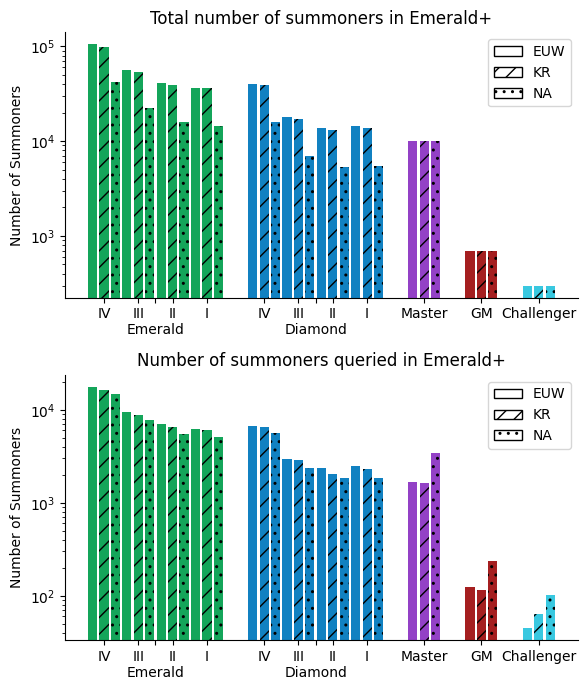

In [7]:
xvals = flatten([[x for x in vals] for vals in [range(0,12),range(14,26),range(28,31),range(33,36),range(38,41)]])

colors = ['#14a55a']*12 + ['#1181c1']*12 + ['#9341c6']*3 + ['#a51f20']*3 + ['#39c8e0']*3
hatches = ['','//','..']*11

legend_elements = [
    Patch(
        facecolor='white',
        hatch = '',
        edgecolor='k',
        label='EUW'
    ),
    Patch(
        facecolor='white',
        hatch = '//',
        edgecolor='k',
        label='KR'
    ),
    Patch(
        facecolor='white',
        hatch = '..',
        edgecolor='k',
        label='NA'
    )
]

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,7))
ax1.bar(
    xvals,
    tier_sizes_expand,
    color = colors,
    hatch=hatches
)

ax1.set_xticks([1,4,7,10,15,18,21,24,5.5,19.5,29,34,39])
ax1.set_xticklabels(['IV','III','II','I']*2 + ['\nEmerald','\nDiamond','Master','GM','Challenger'])

ax1.set_ylabel('Number of Summoners')
ax1.set_yscale('log')

ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.legend(handles = legend_elements)
ax1.set_title('Total number of summoners in Emerald+')

ax2.bar(
    xvals,
    tier_sampled_expand,
    color = colors,
    hatch=hatches
)

ax2.set_xticks([1,4,7,10,15,18,21,24,5.5,19.5,29,34,39])
ax2.set_xticklabels(['IV','III','II','I']*2 + ['\nEmerald','\nDiamond','Master','GM','Challenger'])

ax2.set_ylabel('Number of Summoners')
ax2.set_yscale('log')

ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.legend(handles = legend_elements)
ax2.set_title('Number of summoners queried in Emerald+')
fig.tight_layout()

The above bar graphs show the distributions of the total and queried number of summoners. Importantly we see that the distributions for a given region mirror themselves between the total and queried amounts suggesting an even random sampling. Additionally the numbers for the total match our expectations of the data: the less-skilled tier Emerald is larger than the more-skilled tier Diamond, there are decreasing amounts of summoners for divisions within a tier, and there's a fixed number of Masters/GM/Challenger players across regions. One observation to note is that the NA region appears to be oversampled compared to EUW & KR. The simplest explanation for this is that as I am based in the USA, there's less latency for me to communicate with the NA server compared to EUW and KR. This result however does not mean there is an oversampling of NA games compared to EUW & KR because with the possibility of querying duplicate games, additional queries do not necessarily yield more unique games. Lastly, we don't know if the data is different between regions, so that is a question to explore later. 

In [11]:
from scipy.stats import binomtest

In [13]:
euw_sampled = tier_sampled_expand[0::3]
euw_sizes = tier_sizes_expand[0::3]

kr_sampled = tier_sampled_expand[1::3]
kr_sizes = tier_sizes_expand[1::3]

na_sampled = tier_sampled_expand[2::3]
na_sizes = tier_sizes_expand[2::3]

In [16]:
binom_euw = [binomtest(n,k,p=np.sum(euw_sampled)/np.sum(euw_sizes)) for n,k in zip(euw_sampled,euw_sizes)]
binom_kr = [binomtest(n,k,p=np.sum(kr_sampled)/np.sum(kr_sizes)) for n,k in zip(kr_sampled,kr_sizes)]
binom_na = [binomtest(n,k,p=np.sum(na_sampled)/np.sum(na_sizes)) for n,k in zip(na_sampled,na_sizes)]

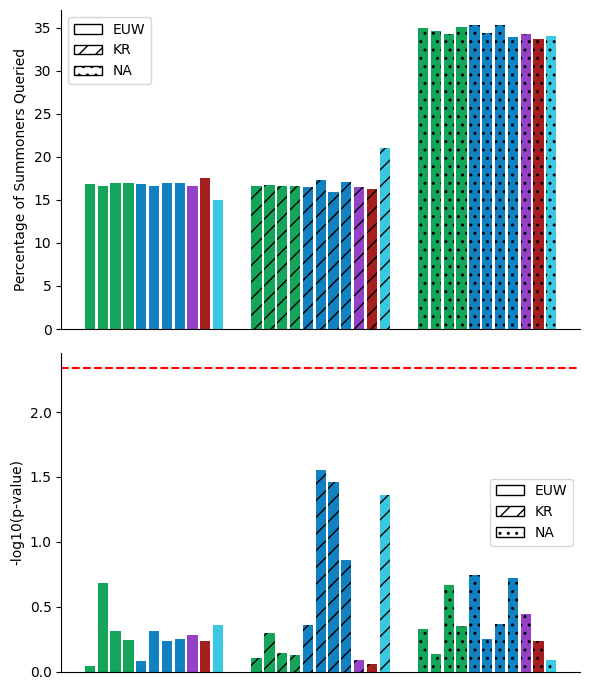

In [28]:
xvals = flatten([[x for x in vals] for vals in [range(0,11),range(13,24),range(26,37)]])

colors = (['#14a55a']*4 + ['#1181c1']*4 + ['#9341c6'] + ['#a51f20'] + ['#39c8e0'])*3
hatches = ['']*11 + ['//']*11 + ['..']*11

legend_elements = [
    Patch(
        facecolor='white',
        hatch = '',
        edgecolor='k',
        label='EUW'
    ),
    Patch(
        facecolor='white',
        hatch = '//',
        edgecolor='k',
        label='KR'
    ),
    Patch(
        facecolor='white',
        hatch = '..',
        edgecolor='k',
        label='NA'
    )
]

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,7))
ax1.bar(
    xvals,
    [result.statistic*100 for result in binom_euw+binom_kr+binom_na],
    color = colors,
    hatch=hatches
)

ax1.set_xticks([])

ax1.set_ylabel('Percentage of Summoners Queried')

ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.legend(handles = legend_elements)

ax2.bar(
    xvals,
    [-np.log10(result.pvalue) for result in binom_euw+binom_kr+binom_na],
    color = colors,
    hatch=hatches
)
ax2.axhline(-np.log10(0.05/11),c='r',linestyle='--')

ax2.set_xticks([])
ax2.set_ylabel('-log10(p-value)')

ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.legend(handles = legend_elements)
fig.tight_layout()

To more rigorously test our random sampling of summoners from each region, I employed a binomial test. A binomial test is how we determine if a coin (binary outcome) matches our expected probability. We can compare how our chance of sampling (is sampled/is not sampled) within a tier & division for a region compares to the global sampling of that region. I performed a Bonferroni correction on the p-value to account for the multiple testing within each region which changes our threshold of p-value significance from 0.05 to 0.05/11=0.0045 which is visualized by the dotted red line in the bottom graph. Because all of our p-values fall below the level of significance, there is no tier/division that is significantly overrepresented in the sampling.

Note: My personal opinion of p-value correction is that it's more of an art than a science. On one hand, you don't want to lose possible significant observations and on the other, you don't want to be investigating false positives. At it's core, the p-value is a uniform distribution, so with 100 observations, 5 would be expected to be below a p-value threshold of 0.05. So we know from how we constructed this scenario of 100 observations that none are necessarily different than the other. In this instance of our random sampling, we also have no reason to believe that the sampling of one tier & division is any different than the other which is why I would justify the use of a p-value correction. There can certainly be other scenarios where I perform multiple statistical tests that I would not correct for a p-value because of my understanding of the problem.